In [13]:
import pandas as pd


df = pd.read_csv('winequality-red.csv', sep=None, engine='python')

print("Fixed Columns:", df.columns.tolist())

# Show the first 5 rows to confirm it looks like a proper table
df.head()

Fixed Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [14]:
#Identify and Remove Duplicates
#Chemical profiles for different wine samples can sometimes be identical in raw data, leading to duplicates that might bias your analysis.

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates to ensure each sample is unique
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully!")
    
# Check the new shape of the data
print(f"Data shape after cleaning: {df.shape}")

Number of duplicate rows: 240
Duplicates removed successfully!
Data shape after cleaning: (1359, 12)


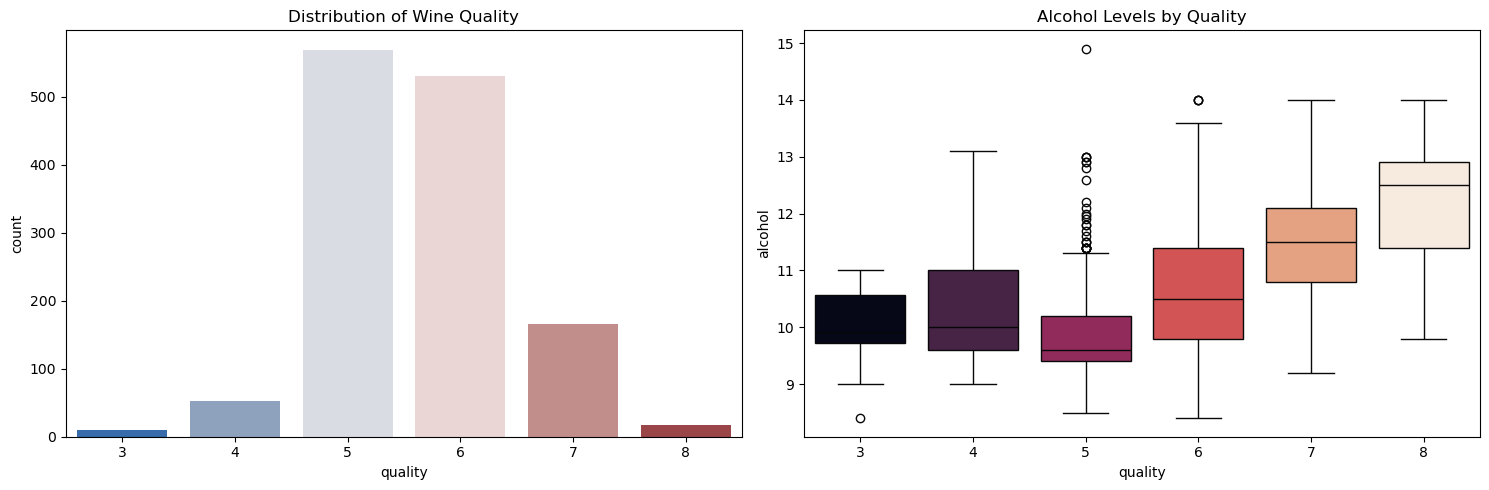


Missing values check:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Finalizing Clean Data: Handling Outliers for better storytelling
# Let's cap 'total sulfur dioxide' at the 99th percentile to remove extreme outliers
q_limit = df['total sulfur dioxide'].quantile(0.99)
df = df[df['total sulfur dioxide'] < q_limit]

# 2. Visualizing the Imbalance and Alcohol Content (Clean Version)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Quality distribution
# This confirms the class imbalance: more normal wines than excellent/poor ones
sns.countplot(x='quality', hue='quality', data=df, ax=ax[0], palette='vlag', legend=False)
ax[0].set_title('Distribution of Wine Quality')

# Plot 2: Alcohol vs Quality
# Visualizes if higher alcohol correlates to higher sensory quality
sns.boxplot(x='quality', y='alcohol', hue='quality', data=df, ax=ax[1], palette='rocket', legend=False)
ax[1].set_title('Alcohol Levels by Quality')

plt.tight_layout()
plt.show()

# 3. Check for Nulls
print("\nMissing values check:")
print(df.isnull().sum())

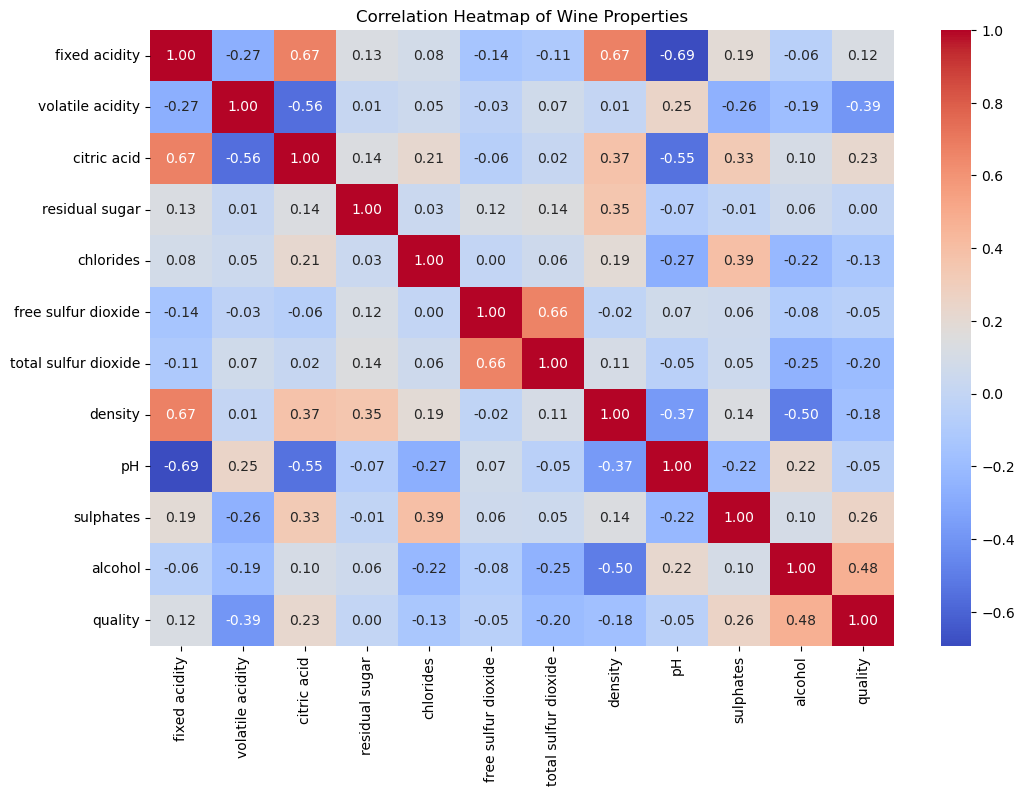

In [16]:
# Advanced Visualization & Storytelling
#Now that the data is clean, we need to find the "Why." Why are some wines rated an 8 while others are a 3?

plt.figure(figsize=(12, 8))
# Calculating correlation between all physicochemical variables[cite: 1]
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Wine Properties')
plt.show()

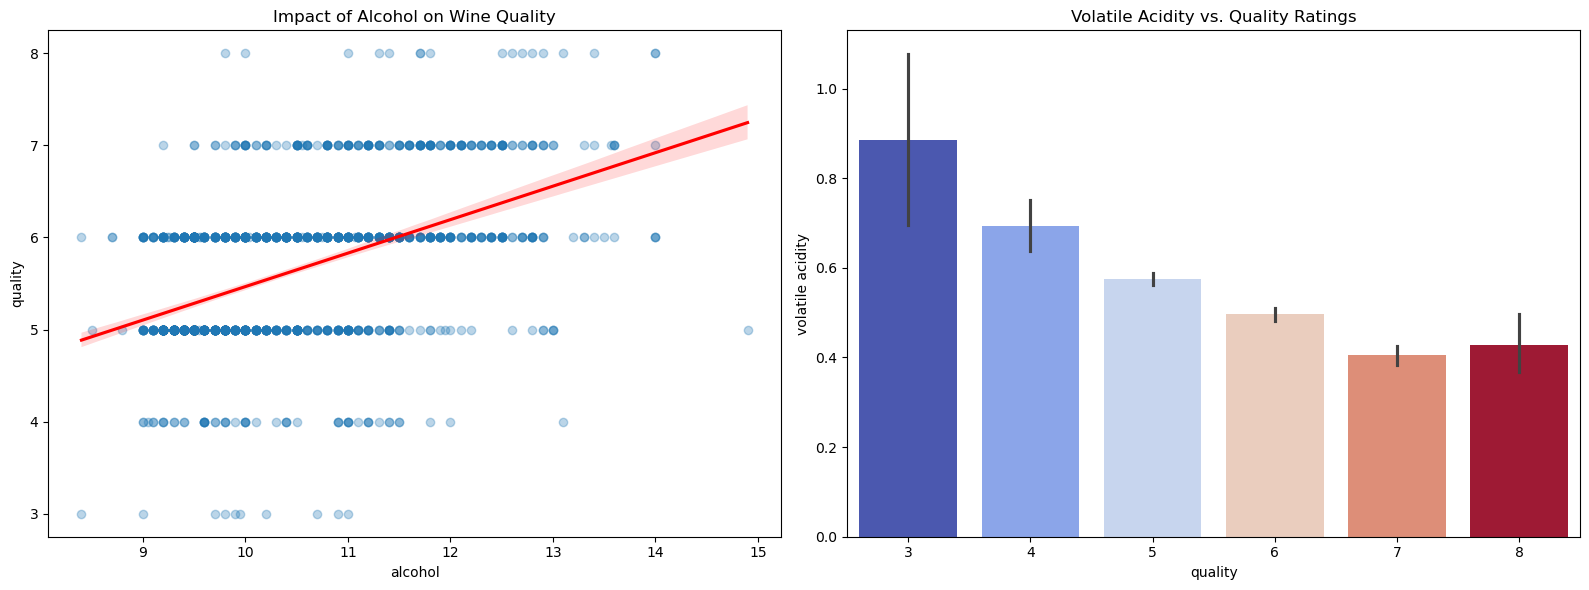

In [17]:
#Final Visualizations & Storytelling

# Create a multi-plot figure to show the 'Story' of the data
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: The 'Positive' Story (Alcohol)
sns.regplot(x='alcohol', y='quality', data=df, ax=ax[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
ax[0].set_title('Impact of Alcohol on Wine Quality')

# Plot 2: The 'Negative' Story (Volatile Acidity)
sns.barplot(x='quality', y='volatile acidity', hue='quality', data=df, ax=ax[1], palette='coolwarm', legend=False)
ax[1].set_title('Volatile Acidity vs. Quality Ratings')

plt.tight_layout()
plt.show()